<a href="https://colab.research.google.com/github/marcoLO897/Tesis_Consumo_Agua/blob/main/Clasificaci%C3%B3n_Modelos_Tesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Montar Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import random

#librerias de modelos
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Datasets_tesis/df_KFTE.csv')
df_1 = pd.read_csv('/content/drive/MyDrive/Datasets_tesis/df_sin_conv.csv')

In [ ]:
# Definir el orden jerárquico
mapeo_clases = {
    'POPULAR': 0,
    'BAJO': 1,
    'MEDIO': 2,
    'ALTO': 3
}

In [ ]:
X = df.drop(['indice_des', 'Unnamed: 0'], axis=1)
y_raw = df['indice_des']

In [ ]:
y = y_raw.map(mapeo_clases)

# **KNN**

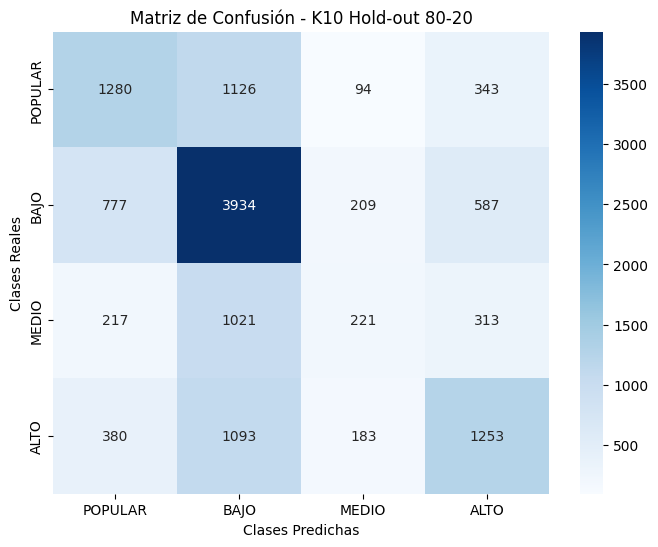

In [ ]:
#División Hold-out 80-20 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

#Inicialización y entrenamiento de kNN
knn = KNeighborsClassifier(n_neighbors=10, n_jobs=-1)
knn.fit(X_train, y_train)

#Predicción sobre el conjunto de test
y_pred_KNN = knn.predict(X_test)

#Cálculo y visualización exclusiva de la Matriz de Confusión
cm_KNN = confusion_matrix(y_test, y_pred_KNN)

# Configurar la visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm_KNN, annot=True, fmt='d', cmap='Blues',
            xticklabels=mapeo_clases.keys(),
            yticklabels=mapeo_clases.keys())

plt.title('Matriz de Confusión - K10 Hold-out 80-20')
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.show()

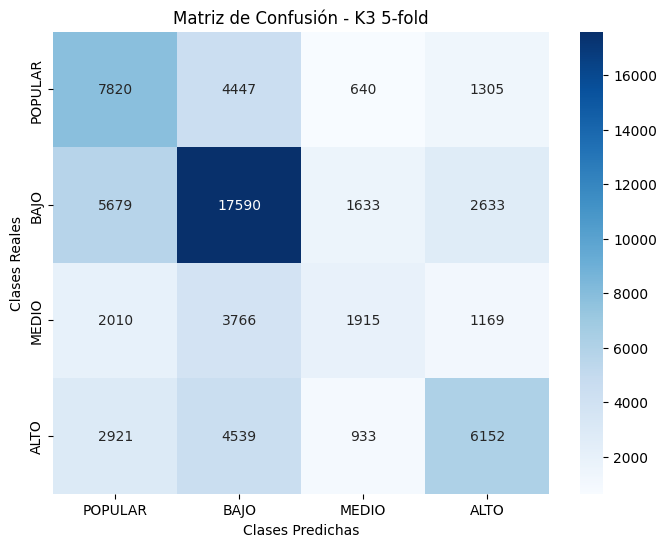

In [ ]:
#Configuración de los 5 Folds Estratificados
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

#Inicialización del modelo kNN
knn_cv = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)

#Generación de predicciones out-of-fold para todo el dataset
y_pred_KNN_cv = cross_val_predict(knn_cv, X, y, cv=cv, n_jobs=-1)

#Cálculo y visualización exclusiva de la Matriz de Confusión
cm_KNN = confusion_matrix(y, y_pred_KNN_cv)

# Configurar la visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm_KNN, annot=True, fmt='d', cmap='Blues',
            xticklabels=mapeo_clases.keys(),
            yticklabels=mapeo_clases.keys())

plt.title('Matriz de Confusión - K3 5-fold')
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.show()

In [ ]:
me_dempeño(cm_KNN)

Medidas de desempeño Clase 0
Recall : 0.5502
Precision : 0.4243
Specificity : 0.7917157440125638
Balance Accuracy : 0.671
F1-Score : 0.4791
MCC : 0.31354697883103383
Medidas de desempeño Clase 1
Recall : 0.6388
Precision : 0.5797
Specificity : 0.6610043331472473
Balance Accuracy : 0.6499
F1-Score : 0.6078
MCC : 0.29691503151922227
Medidas de desempeño Clase 2
Recall : 0.2161
Precision : 0.374
Specificity : 0.9430469693739786
Balance Accuracy : 0.5796
F1-Score : 0.2739
MCC : 0.20276006185928702
Medidas de desempeño Clase 3
Recall : 0.423
Precision : 0.5464
Specificity : 0.8990851068034067
Balance Accuracy : 0.661
F1-Score : 0.4768
MCC : 0.35470483938384195
Medidas de desempeño Macro
Precision macro: 0.4811
Recall macro: 0.457
Specificity macro: 0.8237
F1 macro: 0.4594
MCC macro: 0.292
Balance Accuaracy macro: 0.6404


# **SVM**

Validacion Hold-out 80-20

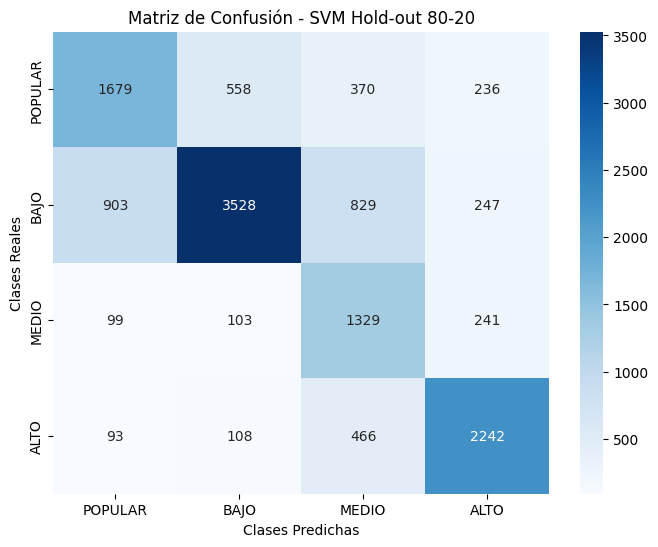

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

#División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

#Normalización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced', # Para manejar el desbalance de tus clases
    random_state=42
)

#Entrenamiento (Nota: SVM puede tardar más que RF en datasets de ~65k)
modelo_svm.fit(X_train_scaled, y_train)

#Predicción
y_pred_svm = modelo_svm.predict(X_test_scaled)

#Calcular la matriz
cm_svm = confusion_matrix(y_test, y_pred_svm)

#Configurar la visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=mapeo_clases.keys(),
            yticklabels=mapeo_clases.keys())

plt.title('Matriz de Confusión - SVM Hold-out 80-20')
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.show()

Ejecutando validación cruzada para 5-Fold... (Esto puede demorar)
¡5-Fold completado con éxito!
Ejecutando validación cruzada para 10-Fold... (Esto puede demorar)
¡10-Fold completado con éxito!


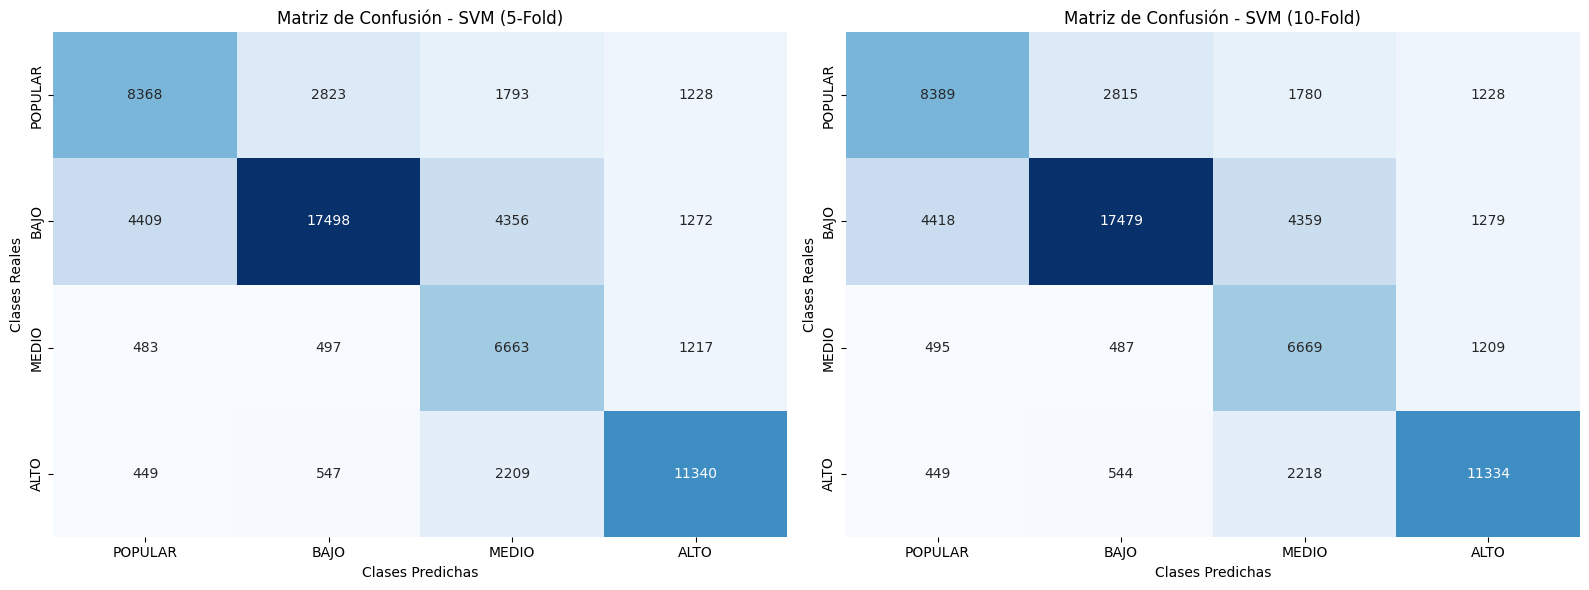


REPORTE DE RENDIMIENTO DETALLADO - CONFIGURACIÓN OPTIMA (10-FOLD)
              precision    recall  f1-score   support

     POPULAR       0.61      0.59      0.60     14212
        BAJO       0.82      0.63      0.72     27535
       MEDIO       0.44      0.75      0.56      8860
        ALTO       0.75      0.78      0.77     14545

    accuracy                           0.67     65152
   macro avg       0.66      0.69      0.66     65152
weighted avg       0.71      0.67      0.68     65152



In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report

#Definir los esquemas de validación cruzada
configuraciones_kfold = {
    '5-Fold': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    '10-Fold': StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
}

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',
        random_state=42
    ))
])

# Diccionario para almacenar las predicciones de cada configuración
predicciones_por_kfold = {}

#Ejecutar los experimentos
for nombre, cv_estrategia in configuraciones_kfold.items():

    y_pred_cv = cross_val_predict(pipeline_svm, X, y, cv=cv_estrategia, n_jobs=-1)
    predicciones_por_kfold[nombre] = y_pred_cv

    print(f"¡{nombre} completado con éxito!")

#Generar y graficar las Matrices de Confusión de manera simultánea
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (nombre, y_pred) in enumerate(predicciones_por_kfold.items()):

    cm = confusion_matrix(y, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=mapeo_clases.keys(),
                yticklabels=mapeo_clases.keys(),
                ax=axes[idx], cbar=False)

    axes[idx].set_title(f'Matriz de Confusión - SVM ({nombre})')
    axes[idx].set_xlabel('Clases Predichas')
    axes[idx].set_ylabel('Clases Reales')

plt.tight_layout()
plt.show()

#Reportar métricas detalladas para la mejor configuración (10-Fold)

print(classification_report(y, predicciones_por_kfold['10-Fold'], target_names=mapeo_clases.keys()))

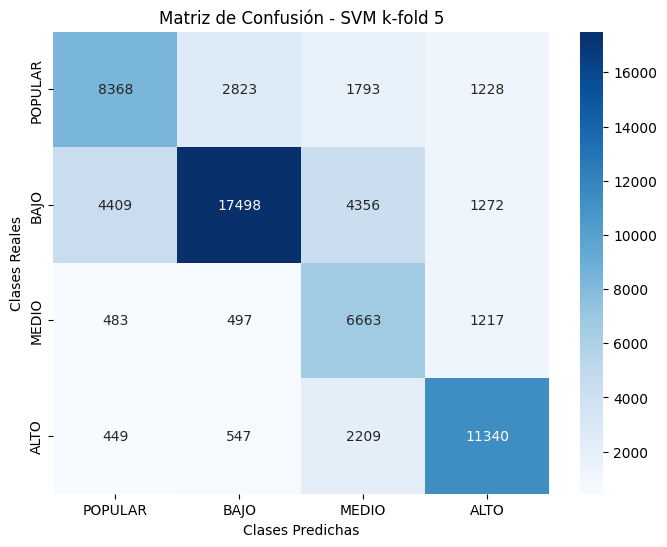

In [ ]:
#Configurar la visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=mapeo_clases.keys(),
            yticklabels=mapeo_clases.keys())

plt.title('Matriz de Confusión - SVM k-fold 5')
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.show()

In [ ]:
me_dempeño(cm_svm)

Medidas de desempeño Clase 0
Recall : 0.5903
Precision : 0.6101
Specificity : 0.8947389085198273
Balance Accuracy : 0.7425
F1-Score : 0.6
MCC : 0.49086161798703565
Medidas de desempeño Clase 1
Recall : 0.6348
Precision : 0.8196
Specificity : 0.8977589919451312
Balance Accuracy : 0.7663
F1-Score : 0.7155
MCC : 0.5606353687933768
Medidas de desempeño Clase 2
Recall : 0.7527
Precision : 0.4438
Specificity : 0.8515419597811412
Balance Accuracy : 0.8021
F1-Score : 0.5584
MCC : 0.4917045092358887
Medidas de desempeño Clase 3
Recall : 0.7792
Precision : 0.7531
Specificity : 0.9265714229256822
Balance Accuracy : 0.8529
F1-Score : 0.7659
MCC : 0.6973537219881804
Medidas de desempeño Macro
Precision macro: 0.6566
Recall macro: 0.6892
Specificity macro: 0.8927
F1 macro: 0.66
MCC macro: 0.5601
Balance Accuaracy macro: 0.791


# **Naive Bayes**

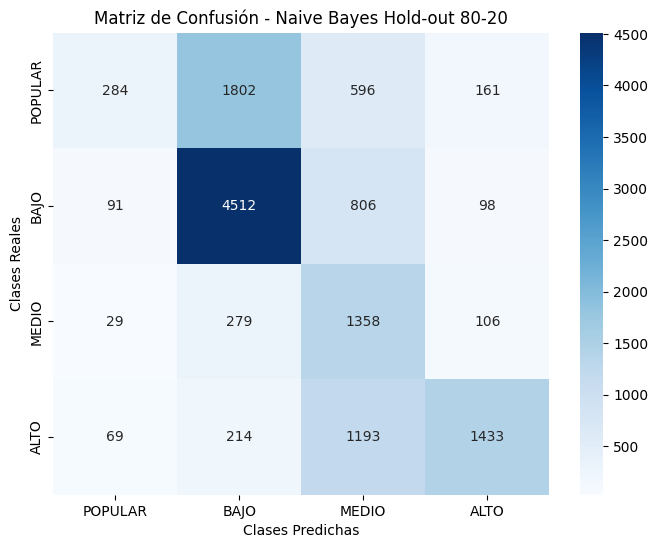

In [ ]:
#División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Configuración del modelo
modelo_nb = GaussianNB()

#Entrenamiento
modelo_nb.fit(X_train, y_train)

#Predicción
y_pred_nb = modelo_nb.predict(X_test)

# Calcular la matriz
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Configurar la visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=mapeo_clases.keys(),
            yticklabels=mapeo_clases.keys())

plt.title('Matriz de Confusión - Naive Bayes Hold-out 80-20')
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.show()

Validacion cruzada

Ejecutando validación cruzada para Naive Bayes (5-Fold)...
¡5-Fold completado con éxito!


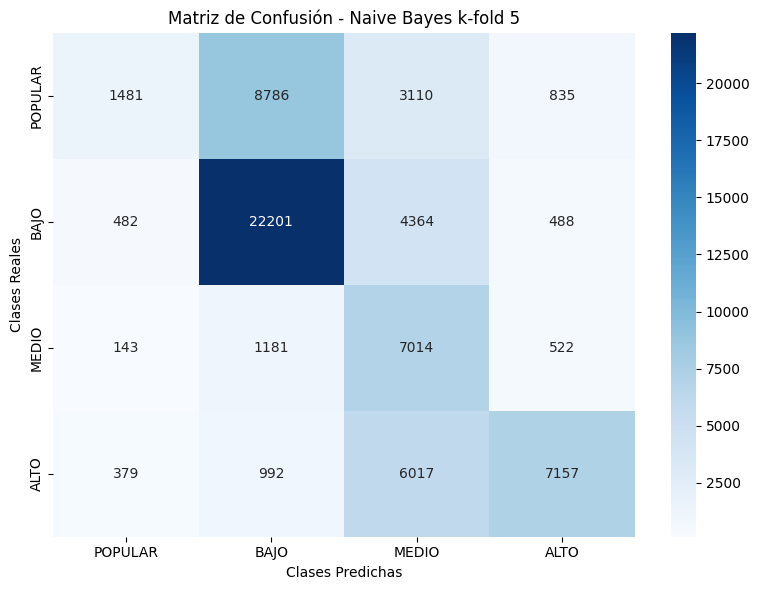

In [ ]:
#Configuración del esquema de validación cruzada (5-Fold Estratificado)
cv_estrategia = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Configuración del modelo
modelo_nb = GaussianNB()

#Entrenamiento y Predicción mediante Validación Cruzada
y_pred_nb_cv = cross_val_predict(modelo_nb, X, y, cv=cv_estrategia, n_jobs=-1)

#Calcular la matriz de confusión global del K-Fold
cm_nb = confusion_matrix(y, y_pred_nb_cv)

#Configurar la visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=mapeo_clases.keys(),
            yticklabels=mapeo_clases.keys())

plt.title('Matriz de Confusión - Naive Bayes k-fold 5')
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.tight_layout()
plt.show()

In [ ]:
me_dempeño(cm_nb)

Medidas de desempeño Clase 0
Recall : 0.1042
Precision : 0.596
Specificity : 0.980290537887711
Balance Accuracy : 0.5422
F1-Score : 0.1774
MCC : 0.1821889923397637
Medidas de desempeño Clase 1
Recall : 0.8063
Precision : 0.6695
Specificity : 0.7086689528670548
Balance Accuracy : 0.7575
F1-Score : 0.7316
MCC : 0.5088306905493589
Medidas de desempeño Clase 2
Recall : 0.7916
Precision : 0.3421
Specificity : 0.7603389469196333
Balance Accuracy : 0.776
F1-Score : 0.4777
MCC : 0.40742048994031893
Medidas de desempeño Clase 3
Recall : 0.4921
Precision : 0.795
Specificity : 0.9635425929219278
Balance Accuracy : 0.7278
F1-Score : 0.6079
MCC : 0.5497979667552323
Medidas de desempeño Macro
Precision macro: 0.6006
Recall macro: 0.5486
Specificity macro: 0.8532
F1 macro: 0.4986
MCC macro: 0.4121
Balance Accuaracy macro: 0.7009


# **Modelos arbol de decision**

validación hold-out

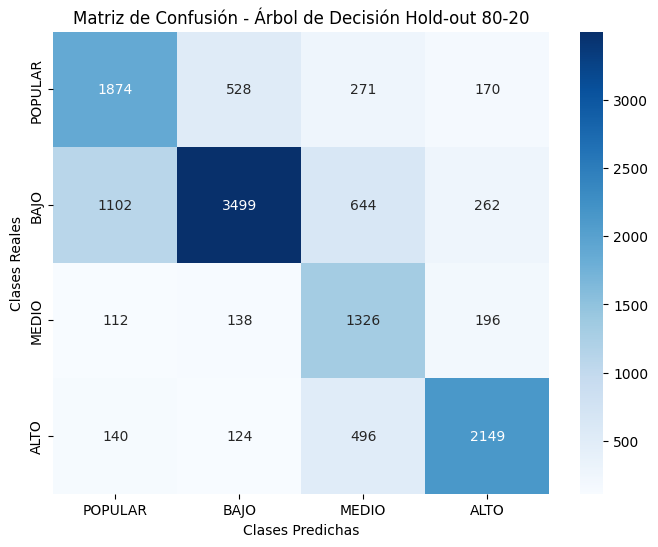

In [ ]:
#División de datos (Hold-out 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Definición del modelo con parámetros de poda
modelo_dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=12,
    min_samples_leaf=15,
    class_weight='balanced',
    random_state=42
)

#Entrenamiento
modelo_dt.fit(X_train, y_train)

#Predicción y Evaluación
y_pred_AD = modelo_dt.predict(X_test)
#print(classification_report(y_test, y_pred))

#Calcular la matriz
cm_AD = confusion_matrix(y_test, y_pred_AD)

#Configurar la visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm_AD, annot=True, fmt='d', cmap='Blues',
            xticklabels=mapeo_clases.keys(),
            yticklabels=mapeo_clases.keys())

plt.title('Matriz de Confusión - Árbol de Decisión Hold-out 80-20')
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.show()

In [ ]:
me_dempeño(cm_AD)

Medidas de desempeño Clase 0
Recall : 0.6592
Precision : 0.5805
Specificity : 0.8670985473105615
Balance Accuracy : 0.7631
F1-Score : 0.6174
MCC : 0.5034868743859292
Medidas de desempeño Clase 1
Recall : 0.6354
Precision : 0.8158
Specificity : 0.8950026581605529
Balance Accuracy : 0.7652
F1-Score : 0.7144
MCC : 0.5575479500525234
Medidas de desempeño Clase 2
Recall : 0.7483
Precision : 0.4845
Specificity : 0.8746780353494982
Balance Accuracy : 0.8115
F1-Score : 0.5882
MCC : 0.5242396931602722
Medidas de desempeño Clase 3
Recall : 0.7387
Precision : 0.7739
Specificity : 0.9379569255087927
Balance Accuracy : 0.8383
F1-Score : 0.7559
MCC : 0.6881225849656555
Medidas de desempeño Macro
Precision macro: 0.6637
Recall macro: 0.6954
Specificity macro: 0.8937
F1 macro: 0.669
MCC macro: 0.5683
Balance Accuaracy macro: 0.7945


Validación k-fold

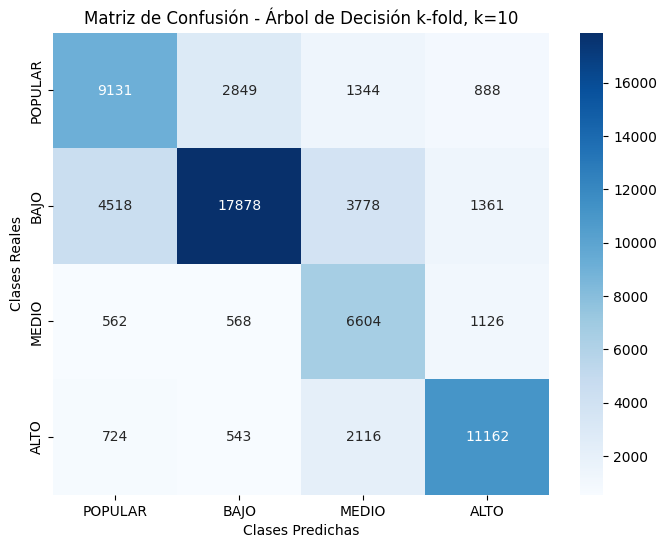

In [ ]:
#Definición del modelo base
modelo_dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=12,
    min_samples_leaf=15,
    class_weight='balanced',
    random_state=42
)

#Configuración de K-Fold (5 pliegues, estratificado)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Generación de predicciones out-of-fold para todo el dataset
y_pred_ADK = cross_val_predict(modelo_dt, X, y, cv=cv, n_jobs=-1)
y_test = y

# Calcular la matriz
cm_ADK = confusion_matrix(y_test, y_pred_ADK)

# Configurar la visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ADK, annot=True, fmt='d', cmap='Blues',
            xticklabels=mapeo_clases.keys(),
            yticklabels=mapeo_clases.keys())

plt.title('Matriz de Confusión - Árbol de Decisión k-fold, k=10')
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.show()

In [ ]:
me_dempeño(cm_ADK)

Medidas de desempeño Clase 0
Recall : 0.6425
Precision : 0.6114
Specificity : 0.886062033765214
Balance Accuracy : 0.7643
F1-Score : 0.6266
MCC : 0.5192935136154408
Medidas de desempeño Clase 1
Recall : 0.6493
Precision : 0.8187
Specificity : 0.8947284472445969
Balance Accuracy : 0.772
F1-Score : 0.7242
MCC : 0.5692746771691859
Medidas de desempeño Clase 2
Recall : 0.7454
Precision : 0.4771
Specificity : 0.871420450508065
Balance Accuracy : 0.8084
F1-Score : 0.5818
MCC : 0.5168674037563411
Medidas de desempeño Clase 3
Recall : 0.7674
Precision : 0.7678
Specificity : 0.9333096211986484
Balance Accuracy : 0.8504
F1-Score : 0.7676
MCC : 0.7008584926813866
Medidas de desempeño Macro
Precision macro: 0.6688
Recall macro: 0.7011
Specificity macro: 0.8964
F1 macro: 0.675
MCC macro: 0.5766
Balance Accuaracy macro: 0.7988


Optimización randomsearch

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, balanced_accuracy_score
from scipy.stats import randint

#División de datos (Hold-out 80/20) para la validación final independiente
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

#Definición del modelo base (fijamos el control de desbalance)
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)

#Definición del Espacio de Búsqueda
espacio_busqueda = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': randint(4, 20),               # Explora profundidades desde 4 hasta 20
    'min_samples_leaf': randint(5, 40),         # Mínimo de muestras en hojas de 5 a 40
    'min_samples_split': randint(10, 80)        # Mínimo de muestras para dividir nodo de 10 a 80
}

#Configuración de RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=dt_base,
    param_distributions=espacio_busqueda,
    n_iter=50,
    scoring='balanced_accuracy',
    cv=5,
    random_state=42,
    n_jobs=-1
)

#Ejecución de la búsqueda en el set de entrenamiento
print("Buscando la configuración óptima...")
random_search.fit(X_train, y_train)

#Despliegue de la mejor combinación encontrada
print("\n=== Mejores Hiperparámetros ===")
print(random_search.best_params_)
print(f"Mejor Balanced Accuracy en validación interna: {random_search.best_score shadow_:.4f}\n" if hasattr(random_search, 'best_score_') else f"Mejor Score: {random_search.best_score_:.4f}\n")

#Extracción del modelo optimizado y evaluación en el conjunto de prueba (Hold-out)
mejor_modelo_dt = random_search.best_estimator_
y_pred_AD = mejor_modelo_dt.predict(X_test)

print("=== Reporte de Clasificación Final (Datos de Prueba) ===")
print(classification_report(y_test, y_pred_AD))
print(f"Balanced Accuracy Final: {balanced_accuracy_score(y_test, y_pred_AD):.4f}")

# **Radom Forest**

Validacion hold out 80-20

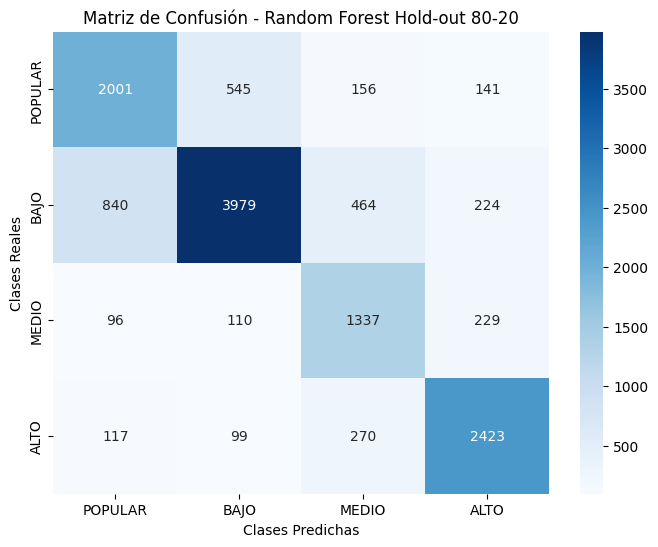

In [ ]:
from sklearn.ensemble import RandomForestClassifier

#Preparación de datos (X = características, y = clase numérica 0-3)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


# Configuración del Bosque Aleatorio
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

#Entrenamiento
modelo_rf.fit(X_train, y_train)

#Predicción
y_pred_rf = modelo_rf.predict(X_test)

# Calcular la matriz
cm_RF = confusion_matrix(y_test, y_pred_rf)

# Configurar la visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm_RF, annot=True, fmt='d', cmap='Blues',
            xticklabels=mapeo_clases.keys(),
            yticklabels=mapeo_clases.keys())

plt.title('Matriz de Confusión - Random Forest Hold-out 80-20')
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.show()

Validacion cruzada

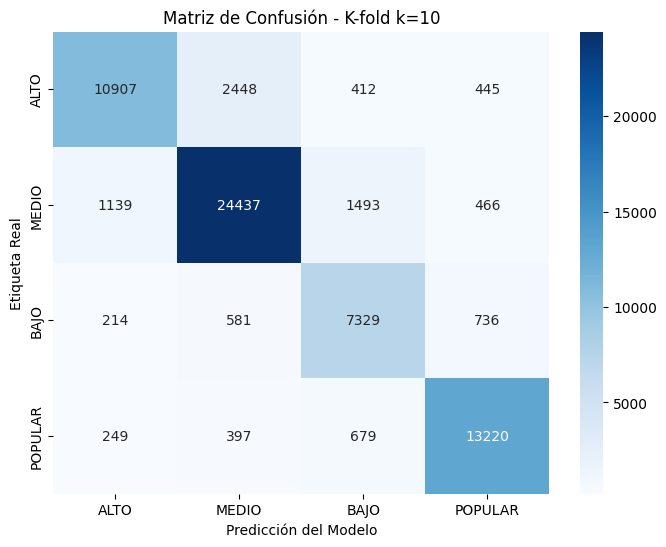

              precision    recall  f1-score   support

           0       0.87      0.77      0.82     14212
           1       0.88      0.89      0.88     27535
           2       0.74      0.83      0.78      8860
           3       0.89      0.91      0.90     14545

    accuracy                           0.86     65152
   macro avg       0.84      0.85      0.84     65152
weighted avg       0.86      0.86      0.86     65152



In [ ]:
from sklearn.model_selection import cross_val_predict, KFold
#Configuración del modelo y la validación
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Definimos el K-fold (ejemplo con K=5 como mencionaste)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

#Generar predicciones mediante Validación Cruzada
y_pred_kfold = cross_val_predict(modelo_rf, X, y, cv=kf)

#Obtener la Matriz de Confusión Global
cm_RF = confusion_matrix(y, y_pred_kfold)

#Visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm_RF, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ALTO', 'MEDIO', 'BAJO', 'POPULAR'],
            yticklabels=['ALTO', 'MEDIO', 'BAJO', 'POPULAR'])
plt.title('Matriz de Confusión - K-fold k=10')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.show()

# Mostrar el reporte para ver F1-Score y Recall por clase
print(classification_report(y, y_pred_kfold))

In [ ]:
me_dempeño(cm_RF)

Medidas de desempeño Clase 0
Recall : 0.7675
Precision : 0.8719
Specificity : 0.9685512367491166
Balance Accuracy : 0.868
F1-Score : 0.8164
MCC : 0.7717098207877638
Medidas de desempeño Clase 1
Recall : 0.8875
Precision : 0.877
Specificity : 0.9089241566313103
Balance Accuracy : 0.8982
F1-Score : 0.8822
MCC : 0.7951856764112926
Medidas de desempeño Clase 2
Recall : 0.8272
Precision : 0.7393
Specificity : 0.9540964968379165
Balance Accuracy : 0.8906
F1-Score : 0.7808
MCC : 0.7456433043046679
Medidas de desempeño Clase 3
Recall : 0.9089
Precision : 0.8892
Specificity : 0.9674550951449404
Balance Accuracy : 0.9382
F1-Score : 0.8989
MCC : 0.8695870505926317
Medidas de desempeño Macro
Precision macro: 0.8444
Recall macro: 0.8478
Specificity macro: 0.9498
F1 macro: 0.8446
MCC macro: 0.7955
Balance Accuaracy macro: 0.8988


Optimización random forest

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

#Redefinimos el espacio buscando eficiencia numérica
param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini'],
    'class_weight': ['balanced']
}

#Configuramos la Búsqueda Aleatoria
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=15,
    cv=5,                # Mantenemos tu validación cruzada K=5 (15 * 5 = 75 entrenamientos totales)
    scoring='f1_macro',  # Priorizamos F1-macro para el desbalance
    n_jobs=-1,           # Usa todos los núcleos de tu procesador
    random_state=42,     # Semilla para que el experimento sea reproducible
    verbose=2            # Para monitorear el progreso en tiempo real
)

#Ejecutar la optimización
print("Iniciando la optimización con RandomizedSearchCV...")
random_search.fit(X, y)

print(f"Mejores parámetros encontrados: {random_search.best_params_}")
print(f"Mejor score obtenido (F1-Macro): {random_search.best_score_:.4f}")

Iniciando la optimización con RandomizedSearchCV...
Fitting 5 folds for each of 15 candidates, totalling 75 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



--- Proceso Completado ---
Mejores parámetros encontrados: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 25, 'criterion': 'gini', 'class_weight': 'balanced'}
Mejor score obtenido (F1-Macro): 0.8361


# **XGBoost**

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:50:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


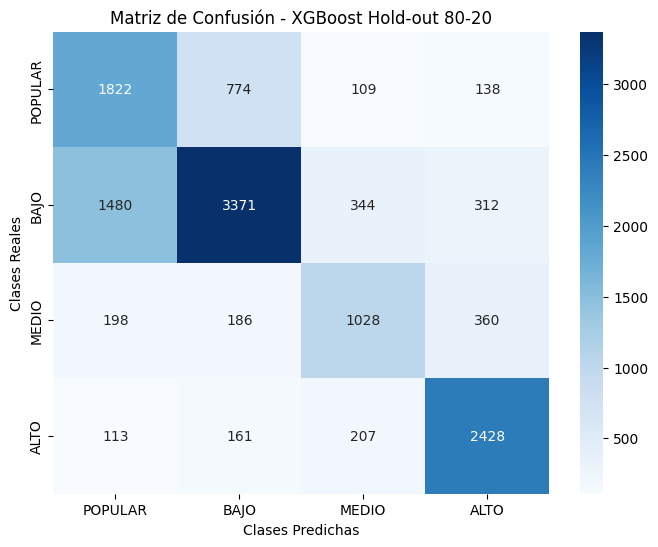

In [ ]:
import xgboost as xgb

#División de datos (usando la misma semilla 42 para comparar)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

#Configuración del modelo XGBoost
modelo_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,             # Profundidad moderada para evitar sobreajuste
    learning_rate=0.1,       # Tasa de aprendizaje (eta)
    objective='multi:softprob', # Probabilidad para multiclase
    eval_metric='mlogloss',   # Métrica de pérdida logarítmica
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

#Entrenamiento
modelo_xgb.fit(X_train, y_train)

#Predicción
y_pred_xgb = modelo_xgb.predict(X_test)

#Calcular la matriz
cm_XB = confusion_matrix(y_test, y_pred_xgb)

# Configurar la visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm_XB, annot=True, fmt='d', cmap='Blues',
            xticklabels=mapeo_clases.keys(),
            yticklabels=mapeo_clases.keys())

plt.title('Matriz de Confusión - XGBoost Hold-out 80-20')
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.show()

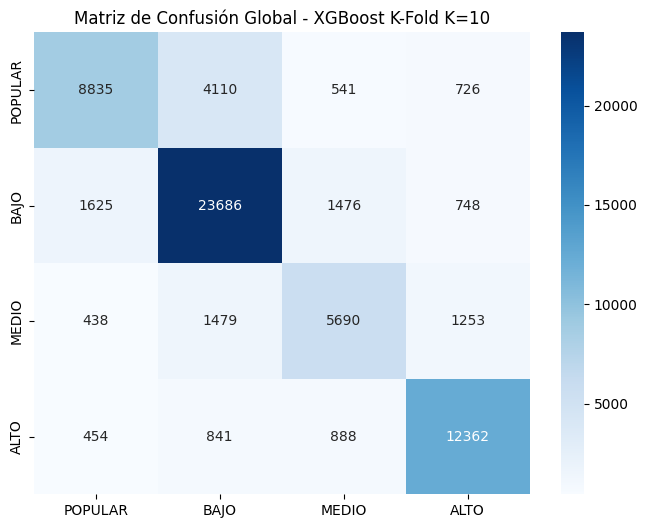

              precision    recall  f1-score   support

           0       0.78      0.62      0.69     14212
           1       0.79      0.86      0.82     27535
           2       0.66      0.64      0.65      8860
           3       0.82      0.85      0.83     14545

    accuracy                           0.78     65152
   macro avg       0.76      0.74      0.75     65152
weighted avg       0.78      0.78      0.77     65152



In [ ]:
#Configuración del modelo XGBoost
modelo_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

#Configuración de K-fold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

#Generar predicciones globales mediante K-fold
y_pred_xgb_kfold = cross_val_predict(modelo_xgb, X, y, cv=kf)

#Generar la Matriz de Confusión
cm_xgb = confusion_matrix(y, y_pred_xgb_kfold)

#Visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['POPULAR', 'BAJO', 'MEDIO', 'ALTO'],
            yticklabels=['POPULAR', 'BAJO', 'MEDIO', 'ALTO'])
plt.title('Matriz de Confusión Global - XGBoost K-Fold K=10')
plt.show()

print(classification_report(y, y_pred_xgb_kfold))

In [ ]:
me_dempeño(cm_xgb)

Medidas de desempeño Clase 0
Recall : 0.6217
Precision : 0.7783
Specificity : 0.9505889281507656
Balance Accuracy : 0.7861
F1-Score : 0.6912
MCC : 0.6230358313102223
Medidas de desempeño Clase 1
Recall : 0.8602
Precision : 0.7865
Specificity : 0.8290666453996863
Balance Accuracy : 0.8446
F1-Score : 0.8217
MCC : 0.6829280826162467
Medidas de desempeño Clase 2
Recall : 0.6422
Precision : 0.662
Specificity : 0.9483940879698713
Balance Accuracy : 0.7953
F1-Score : 0.6519
MCC : 0.5982354384782715
Medidas de desempeño Clase 3
Recall : 0.8499
Precision : 0.8193
Specificity : 0.9461141739285079
Balance Accuracy : 0.898
F1-Score : 0.8343
MCC : 0.7857818010835579
Medidas de desempeño Macro
Precision macro: 0.7615
Recall macro: 0.7435
Specificity macro: 0.9185
F1 macro: 0.7498
MCC macro: 0.6725
Balance Accuaracy macro: 0.831


# **Catboost**

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.0 MB/s eta 0:00:00


In [ ]:
X_cat = df_1.drop(['indice_des', 'Unnamed: 0'], axis=1)
y_cat = df_1['indice_des']

0:	learn: 1.3528110	total: 169ms	remaining: 1m 24s
100:	learn: 0.7457227	total: 11.2s	remaining: 44.1s
200:	learn: 0.6970888	total: 24.7s	remaining: 36.7s
300:	learn: 0.6665962	total: 35.4s	remaining: 23.4s
400:	learn: 0.6468963	total: 46.5s	remaining: 11.5s
499:	learn: 0.6287237	total: 57.4s	remaining: 0us


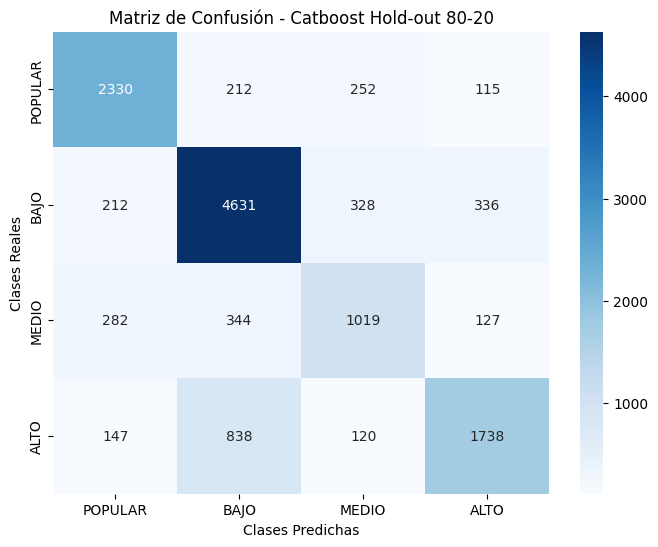

In [ ]:
cat_features = ['alcaldia', 'colonia']

X_train, X_test, y_train, y_test = train_test_split(
    X_cat,
    y_cat,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

y_pred_cat = model.predict(X_test)

#Calcular la matriz
cm_cat = confusion_matrix(y_test, y_pred_cat)

# Configurar la visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Blues',
            xticklabels=mapeo_clases.keys(),
            yticklabels=mapeo_clases.keys())

plt.title('Matriz de Confusión - Catboost Hold-out 80-20')
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.show()

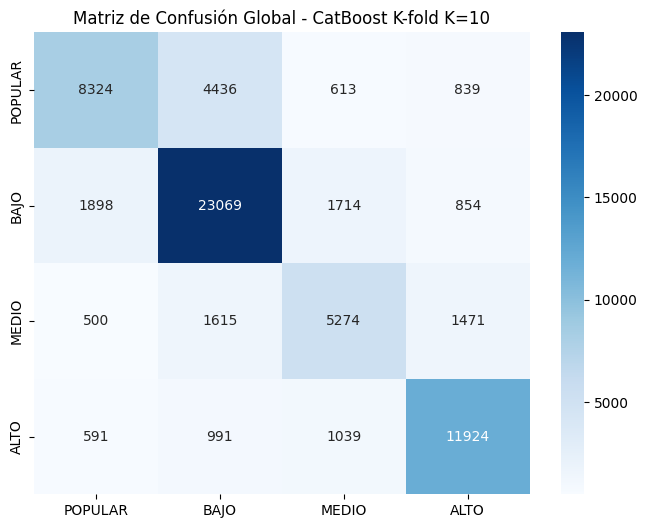

              precision    recall  f1-score   support

           0       0.74      0.59      0.65     14212
           1       0.77      0.84      0.80     27535
           2       0.61      0.60      0.60      8860
           3       0.79      0.82      0.80     14545

    accuracy                           0.75     65152
   macro avg       0.73      0.71      0.72     65152
weighted avg       0.74      0.75      0.74     65152



In [ ]:
from catboost import CatBoostClassifier
#Configuración del modelo CatBoost
modelo_cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    l2_leaf_reg=3,
    loss_function='MultiClass',
    random_seed=42,
    verbose=False
)

#Configuración de K-fold (Misma que usamos en RF y XGBoost)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

#Generar predicciones globales
y_pred_cat_kfold = cross_val_predict(modelo_cat, X, y, cv=kf)

#Generar la Matriz de Confusión
cm_cat = confusion_matrix(y, y_pred_cat_kfold)

#Visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['POPULAR', 'BAJO', 'MEDIO', 'ALTO'],
            yticklabels=['POPULAR', 'BAJO', 'MEDIO', 'ALTO'])
plt.title('Matriz de Confusión Global - CatBoost K-fold K=10')
plt.show()

print(classification_report(y, y_pred_cat_kfold))

In [ ]:
me_dempeño(cm_cat)

Medidas de desempeño Clase 0
Recall : 0.5857
Precision : 0.7358
Specificity : 0.9413231252453867
Balance Accuracy : 0.7635
F1-Score : 0.6522
MCC : 0.5745809037454997
Medidas de desempeño Clase 1
Recall : 0.8378
Precision : 0.7661
Specificity : 0.8127974054283967
Balance Accuracy : 0.8253
F1-Score : 0.8003
MCC : 0.644614991876803
Medidas de desempeño Clase 2
Recall : 0.5953
Precision : 0.6104
Specificity : 0.9402046471967598
Balance Accuracy : 0.7678
F1-Score : 0.6028
MCC : 0.5411821500372077
Medidas de desempeño Clase 3
Recall : 0.8198
Precision : 0.7903
Specificity : 0.9374790048807478
Balance Accuracy : 0.8786
F1-Score : 0.8048
MCC : 0.7475492669602151
Medidas de desempeño Macro
Precision macro: 0.7257
Recall macro: 0.7096
Specificity macro: 0.908
F1 macro: 0.715
MCC macro: 0.627
Balance Accuaracy macro: 0.8088


# **Random Forest optimizado**

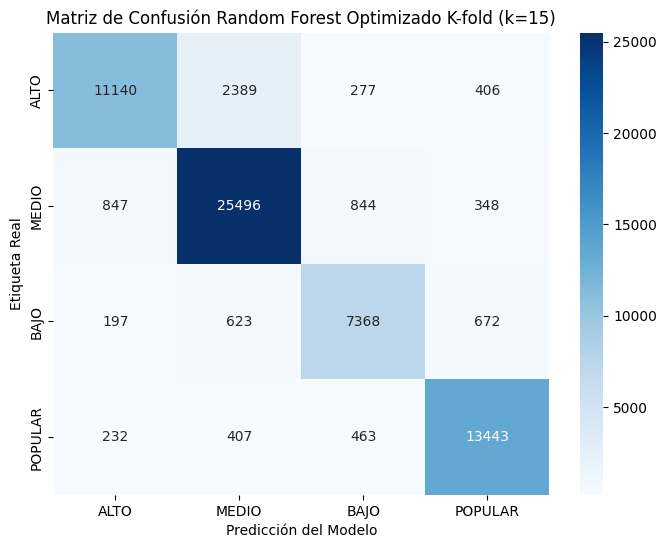

              precision    recall  f1-score   support

           0       0.90      0.78      0.84     14212
           1       0.88      0.93      0.90     27535
           2       0.82      0.83      0.83      8860
           3       0.90      0.92      0.91     14545

    accuracy                           0.88     65152
   macro avg       0.88      0.87      0.87     65152
weighted avg       0.88      0.88      0.88     65152



In [ ]:
#Configuración del modelo y la validación

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=2,
    max_depth=25,
    criterion='gini',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Definimos el K-fold (ejemplo con K=5 como mencionaste)
kf = KFold(n_splits=15, shuffle=True, random_state=42)

#Generar predicciones mediante Validación Cruzada
y_pred_kfold = cross_val_predict(modelo_rf, X, y, cv=kf)

#Obtener la Matriz de Confusión Global
cm = confusion_matrix(y, y_pred_kfold)

#Visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ALTO', 'MEDIO', 'BAJO', 'POPULAR'],
            yticklabels=['ALTO', 'MEDIO', 'BAJO', 'POPULAR'])
plt.title('Matriz de Confusión Random Forest Optimizado K-fold (k=15)')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.show()

print(classification_report(y, y_pred_kfold))

In [ ]:
me_dempeño(cm)

Medidas de desempeño Clase 0
Recall : 0.7838
Precision : 0.8972
Specificity : 0.9749509226541029
Balance Accuracy : 0.8794
F1-Score : 0.8367
MCC : 0.7978796830743062
Medidas de desempeño Clase 1
Recall : 0.9259
Precision : 0.8818
Specificity : 0.9091102427094133
Balance Accuracy : 0.9175
F1-Score : 0.9033
MCC : 0.8302599366778347
Medidas de desempeño Clase 2
Recall : 0.8316
Precision : 0.8231
Specificity : 0.971861010445534
Balance Accuracy : 0.9017
F1-Score : 0.8273
MCC : 0.7999784291058117
Medidas de desempeño Clase 3
Recall : 0.9242
Precision : 0.9041
Specificity : 0.9718220799494142
Balance Accuracy : 0.948
F1-Score : 0.914
MCC : 0.8890914378768768
Medidas de desempeño Macro
Precision macro: 0.8766
Recall macro: 0.8664
Specificity macro: 0.9569
F1 macro: 0.8703
MCC macro: 0.8293
Balance Accuaracy macro: 0.9116


In [ ]:
df_1['indice_des_pred'] = y_pred_kfold

In [ ]:
clase_predominante = (
    df_1.groupby('colonia')['indice_des_pred']
      .agg(lambda x: x.mode().iloc[0])
      .reset_index()
)

In [ ]:
clase_predominante.to_csv(
    '/content/drive/MyDrive/Mapas_tesis/indice_predicha.csv',
    index=False,
    encoding='utf-8-sig'
)

In [ ]:
import geopandas as gpd

gdf = gpd.GeoDataFrame(
    df_1,
    geometry=gpd.points_from_xy(
        df['longitud'],
        df['latitud']
    ),
    crs='EPSG:4326'
)

In [ ]:
gdf.to_file('/content/drive/MyDrive/Mapas_tesis/Mapa_predicho/mapa_predicho.shp')

/tmp/ipykernel_1137/2457992431.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file('/content/drive/MyDrive/Mapas_tesis/Mapa_predicho/mapa_predicho.shp')
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Unnamed: 0' to 'Unnamed_ 0'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'consumo_total_mixto' to 'consumo_to'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'consumo_prom_dom' to 'consumo_pr'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'consumo_total_dom' to 'consumo__1'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'consumo_prom_mixto' to 'consumo__2'
  ogr_w

In [ ]:
alto_colonia = (
    df_1[df_1['indice_des_pred'] == 3]
      .groupby('colonia')
      .size()
      .reset_index(name='tomas_alto')
)

In [ ]:
porcentaje_alto = total_colonia.merge(
    alto_colonia,
    on='colonia',
    how='left'
)

In [ ]:
porcentaje_alto['tomas_alto'] = (
    porcentaje_alto['tomas_alto']
    .fillna(0)
)

In [ ]:
porcentaje_alto['porcentaje_alto'] = (
    porcentaje_alto['tomas_alto']
    / porcentaje_alto['total_tomas']
) * 100

In [ ]:
porcentaje_alto.to_csv(
    '/content/drive/MyDrive/Mapas_tesis/Porcentaje_alto.csv',
    index=False,
    encoding='utf-8-sig'
)

In [ ]:
indice_colonia = (
    df_1.groupby('colonia')['indice_des_pred']
      .mean()
      .reset_index()
)

In [ ]:
indice_colonia.to_csv(
    '/content/drive/MyDrive/Mapas_tesis/indice_colonia.csv',
    index=False,
    encoding='utf-8-sig'
)

In [ ]:
modelo_rf.fit(X_train, y_train)

importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
})

importancia = importancia.sort_values(
    by='Importancia',
    ascending=False
)

importancia

,Variable,Importancia
15,colonia_ALTO,0.127743
17,colonia_MEDIO,0.100912
16,colonia_BAJO,0.099680
18,colonia_POPULAR,0.078510
10,longitud,0.058061
3,consumo_total_dom,0.056518
9,latitud,0.056460
2,consumo_prom_dom,0.050922
6,consumo_prom,0.049101
5,consumo_total,0.047675


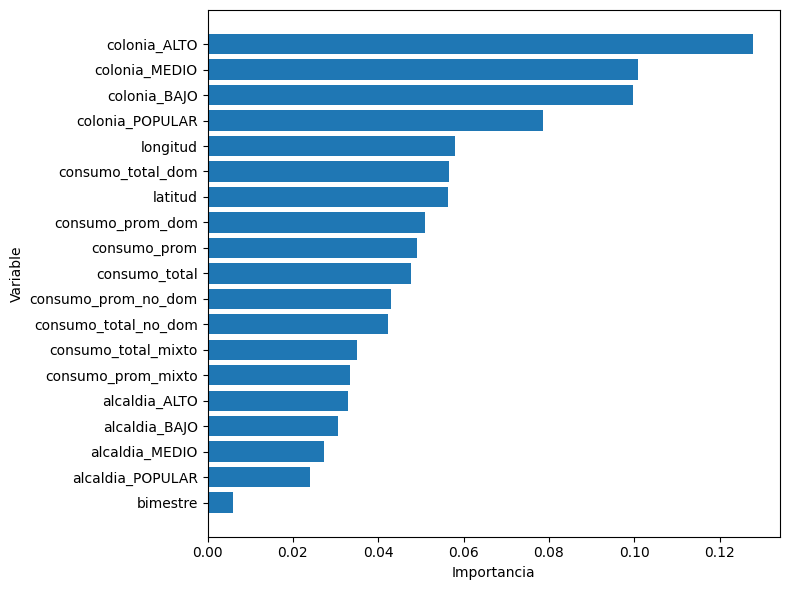

In [ ]:
import matplotlib.pyplot as plt

importancia = importancia.sort_values(
    by='Importancia',
    ascending=True
)

plt.figure(figsize=(8,6))

plt.barh(
    importancia['Variable'],
    importancia['Importancia']
)

plt.xlabel('Importancia')
plt.ylabel('Variable')

plt.tight_layout()
plt.show()

In [ ]:
#Definir K-fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

#Vector para almacenar todas las predicciones y los valores reales
y_real_total = []
y_pred_total = []

#Ciclo manual de K-fold para asegurar el manejo de cat_features
for train_index, test_index in kf.split(X_cat):
    # División de pliegues
    X_train_fold, X_test_fold = X_cat.iloc[train_index], X_cat.iloc[test_index]
    y_train_fold, y_test_fold = y_cat.iloc[train_index], y_cat.iloc[test_index]

    # Configuración del modelo (tu configuración original)
    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function='MultiClass',
        random_seed=42,
        verbose=0 # Silenciamos los logs por cada fold
    )

    # Entrenamiento
    model.fit(
        X_train_fold,
        y_train_fold,
        cat_features=['alcaldia', 'colonia']
    )

    # Predicción y almacenamiento
    preds = model.predict(X_test_fold)

    y_real_total.extend(y_test_fold)
    y_pred_total.extend(preds)

#Generar la Matriz de Confusión Global (K=5)
cm_cat_native = confusion_matrix(y_real_total, y_pred_total)
print("Matriz de Confusión Global (CatBoost Nativo):")
print(cm_cat_native)

#Reporte detallado
print(classification_report(y_real_total, y_pred_total))

Matriz de Confusión Global (CatBoost Nativo):
[[11888   985  1170   502]
 [  961 23214  1806  1554]
 [ 1526  1553  5224   557]
 [  813  4145   634  8620]]
              precision    recall  f1-score   support

        ALTO       0.78      0.82      0.80     14545
        BAJO       0.78      0.84      0.81     27535
       MEDIO       0.59      0.59      0.59      8860
     POPULAR       0.77      0.61      0.68     14212

    accuracy                           0.75     65152
   macro avg       0.73      0.71      0.72     65152
weighted avg       0.75      0.75      0.75     65152



In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd

#Definimos el espacio de búsqueda acotado y estratégico
param_dist_cat = {
    'iterations': [200, 300, 400],           # Reducimos un poco de los 500 base para agilizar
    'learning_rate': [0.03, 0.05, 0.1],      # Ritmos de aprendizaje estándar y robustos
    'depth': [4, 6, 8],                      # Profundidades óptimas para árboles simétricos
    'l2_leaf_reg': [1, 3, 5, 7],             # Regularización L2 para evitar sobreajuste
    'auto_class_weights': ['Balanced']       # Forzamos el balanceo adaptativo por el IR de 3.10
}

#Inicializamos el modelo base silencioso
cat_base = CatBoostClassifier(
    loss_function='MultiClass',
    random_seed=42,
    verbose=False
)

#Configuramos la Búsqueda Aleatoria usando tu mismo kf (K=5)
random_search_cat = RandomizedSearchCV(
    estimator=cat_base,
    param_distributions=param_dist_cat,
    n_iter=10,               # Probará únicamente 10 combinaciones aleatorias
    cv=kf,                   # Tu misma configuración de KFold(n_splits=5, shuffle=True, random_state=42)
    scoring='f1_macro',      # Minimizamos el impacto del desbalance métrico
    n_jobs=-1,               # Distribuye el trabajo en todos tus procesadores
    random_state=42,
    verbose=2
)

#Ejecutar la optimización
print("Iniciando la optimización de CatBoost con RandomizedSearchCV...")
random_search_cat.fit(X, y)

print("\n--- Optimización de CatBoost Completada ---")
print(f"Mejores parámetros encontrados: {random_search_cat.best_params_}")
print(f"Mejor score obtenido (F1-Macro): {random_search_cat.best_score_:.4f}")

Iniciando la optimización de CatBoost con RandomizedSearchCV...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

--- Optimización de CatBoost Completada ---
Mejores parámetros encontrados: {'learning_rate': 0.1, 'l2_leaf_reg': 7, 'iterations': 300, 'depth': 8, 'auto_class_weights': 'Balanced'}
Mejor score obtenido (F1-Macro): 0.7156


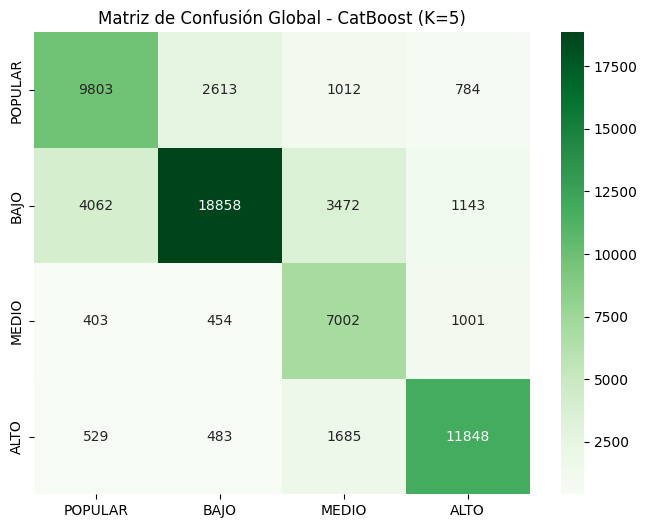

              precision    recall  f1-score   support

           0       0.66      0.69      0.68     14212
           1       0.84      0.68      0.76     27535
           2       0.53      0.79      0.64      8860
           3       0.80      0.81      0.81     14545

    accuracy                           0.73     65152
   macro avg       0.71      0.74      0.72     65152
weighted avg       0.75      0.73      0.73     65152



In [ ]:
#Configuración del modelo CatBoost
#learning_rate': 0.1,
#'l2_leaf_reg': 7,
#'iterations': 300,
#'depth': 8,
#'auto_class_weights': 'Balanced'
modelo_cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=8,
    l2_leaf_reg=7,
    loss_function='MultiClass',
    auto_class_weights= 'Balanced',
    random_seed=42,
    verbose=False  # Para no llenar la pantalla de logs
)

#Configuración de K-fold (Misma que usamos en RF y XGBoost)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

#Generar predicciones globales
y_pred_cat_kfold = cross_val_predict(modelo_cat, X, y, cv=kf)

#Generar la Matriz de Confusión
cm_cat = confusion_matrix(y, y_pred_cat_kfold)

#Visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Greens',
            xticklabels=['POPULAR', 'BAJO', 'MEDIO', 'ALTO'],
            yticklabels=['POPULAR', 'BAJO', 'MEDIO', 'ALTO'])
plt.title('Matriz de Confusión Global - CatBoost (K=5)')
plt.show()

print(classification_report(y, y_pred_cat_kfold))

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

#Definimos el espacio de búsqueda enfocado en la regularización y generalización
param_dist_xgb = {
    'n_estimators': [150, 200, 300],          # Número de árboles de decisión boosting
    'max_depth': [4, 6, 8],                   # Profundidad por árbol (evitamos árboles muy profundos)
    'learning_rate': [0.03, 0.05, 0.1],       # Tasa de aprendizaje o tamaño del paso (eta)
    'subsample': [0.7, 0.8, 1.0],             # Porcentaje de filas a muestrear por cada árbol
    'colsample_bytree': [0.7, 0.8, 1.0]       # Porcentaje de columnas (atributos) a muestrear por árbol
}

#Inicializamos el modelo base con tu configuración
xgb_base = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

#Configurar la Búsqueda Aleatoria usando tu mismo kf (K=5)
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=10,               # 10 combinaciones aleatorias (10 * 5 = 50 entrenamientos totales)
    cv=kf,                   # Tu misma configuración de KFold(n_splits=5, shuffle=True, random_state=42)
    scoring='f1_macro',      # Evaluamos con F1-Macro para cuidar las clases minoritarias
    n_jobs=-1,               # Usa toda la potencia de tu procesador
    random_state=42,
    verbose=2
)

# 4. Ejecutar la optimización
print("Iniciando la optimización de XGBoost con RandomizedSearchCV...")
random_search_xgb.fit(X, y)

print("\n--- Optimización de XGBoost Completada ---")
print(f"Mejores parámetros encontrados: {random_search_xgb.best_params_}")
print(f"Mejor score obtenido (F1-Macro): {random_search_xgb.best_score_:.4f}")

Iniciando la optimización de XGBoost con RandomizedSearchCV...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

--- Optimización de XGBoost Completada ---
Mejores parámetros encontrados: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Mejor score obtenido (F1-Macro): 0.7912


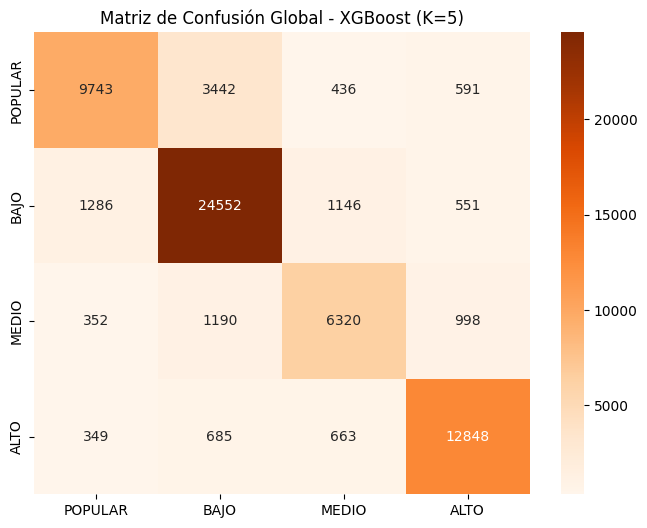

              precision    recall  f1-score   support

           0       0.83      0.69      0.75     14212
           1       0.82      0.89      0.86     27535
           2       0.74      0.71      0.73      8860
           3       0.86      0.88      0.87     14545

    accuracy                           0.82     65152
   macro avg       0.81      0.79      0.80     65152
weighted avg       0.82      0.82      0.82     65152



In [ ]:
#Configuración del modelo XGBoost
modelo_xgb = xgb.XGBClassifier(
    subsample = 0.8,
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    colsample_bytree= 1.0,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

#Configuración de K-fold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

#Generar predicciones globales mediante K-fold
y_pred_xgb_kfold = cross_val_predict(modelo_xgb, X, y, cv=kf)

#Generar la Matriz de Confusión
cm_xgb = confusion_matrix(y, y_pred_xgb_kfold)

#Visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['POPULAR', 'BAJO', 'MEDIO', 'ALTO'],
            yticklabels=['POPULAR', 'BAJO', 'MEDIO', 'ALTO'])
plt.title('Matriz de Confusión Global - XGBoost (K=5)')
plt.show()

print(classification_report(y, y_pred_xgb_kfold))


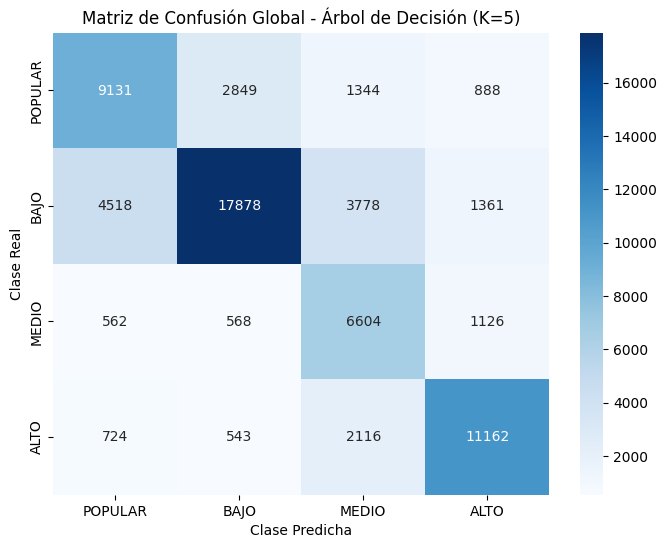

--- Reporte de Clasificación - Árbol de Decisión (K=5) ---
              precision    recall  f1-score   support

           0       0.61      0.64      0.63     14212
           1       0.82      0.65      0.72     27535
           2       0.48      0.75      0.58      8860
           3       0.77      0.77      0.77     14545

    accuracy                           0.69     65152
   macro avg       0.67      0.70      0.68     65152
weighted avg       0.72      0.69      0.69     65152



In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Definición del modelo con tus parámetros de poda originales
modelo_dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=12,            # Evita sobreajuste
    min_samples_leaf=15,     # Estabilidad en las hojas
    class_weight='balanced',  # Manejo de desbalance
    random_state=42
)

#Configuración de K-fold Estratificado (Equivalente a stratify=y)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Generar predicciones globales mediante Validación Cruzada
y_pred_dt_kfold = cross_val_predict(modelo_dt, X, y, cv=skf, n_jobs=-1)

#Generar la Matriz de Confusión Global
cm_dt = confusion_matrix(y, y_pred_dt_kfold)

#Visualización de la Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['POPULAR', 'BAJO', 'MEDIO', 'ALTO'],
            yticklabels=['POPULAR', 'BAJO', 'MEDIO', 'ALTO'])
plt.title('Matriz de Confusión Global - Árbol de Decisión (K=5)')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.show()

#Reporte de Clasificación Final (F1-Macro, Precision, Recall)
print("--- Reporte de Clasificación - Árbol de Decisión (K=5) ---")
print(classification_report(y, y_pred_dt_kfold))

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

# 1. Definimos el espacio de búsqueda enfocado en el control de la poda (Pruning)
param_dist_dt = {
    'criterion': ['gini', 'entropy'],             # Criterio de división de nodos
    'max_depth': [6, 8, 10, 12, 15, 20],          # Profundidad máxima para evitar sobreajuste
    'min_samples_split': [2, 5, 10, 20],          # Mínimo de datos para abrir un nuevo nodo
    'min_samples_leaf': [5, 10, 15, 20, 30],      # Mínimo de datos que debe tener una hoja final
    'class_weight': ['balanced']                  # Penalización para proteger las clases con IR 3.10
}

#Inicializamos el modelo base
dt_base = DecisionTreeClassifier(random_state=42)

#Configuración de K-fold Estratificado (Mismo que usamos para la evaluación)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Configuramos la Búsqueda Aleatoria
random_search_dt = RandomizedSearchCV(
    estimator=dt_base,
    param_distributions=param_dist_dt,
    n_iter=15,               # Evaluará 15 combinaciones al azar (15 * 5 = 75 entrenamientos)
    cv=skf,                  # Validación cruzada estratificada K=5
    scoring='f1_macro',      # Métrica objetivo para mitigar el desbalance
    n_jobs=-1,               # Usa todos los núcleos del procesador
    random_state=42,
    verbose=2
)

#Ejecutar la optimización
print("Iniciando la optimización del Árbol de Decisión con RandomizedSearchCV...")
random_search_dt.fit(X, y)

print("\n--- Optimización del Árbol de Decisión Completada ---")
print(f"Mejores parámetros encontrados: {random_search_dt.best_params_}")
print(f"Mejor score obtenido (F1-Macro): {random_search_dt.best_score_:.4f}")

Iniciando la optimización del Árbol de Decisión con RandomizedSearchCV...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

--- Optimización del Árbol de Decisión Completada ---
Mejores parámetros encontrados: {'min_samples_split': 2, 'min_samples_leaf': 10, 'max_depth': 20, 'criterion': 'gini', 'class_weight': 'balanced'}
Mejor score obtenido (F1-Macro): 0.6973


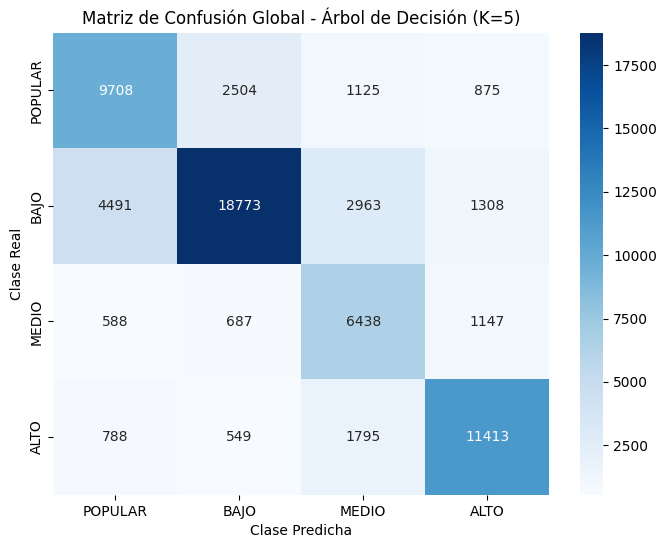

--- Reporte de Clasificación - Árbol de Decisión (K=5) ---
              precision    recall  f1-score   support

           0       0.62      0.68      0.65     14212
           1       0.83      0.68      0.75     27535
           2       0.52      0.73      0.61      8860
           3       0.77      0.78      0.78     14545

    accuracy                           0.71     65152
   macro avg       0.69      0.72      0.70     65152
weighted avg       0.73      0.71      0.72     65152



In [ ]:
#Definición del modelo con tus parámetros de poda originales
modelo_dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=20,
    min_samples_split = 2,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

#Configuración de K-fold Estratificado (Equivalente a stratify=y)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Generar predicciones globales mediante Validación Cruzada
y_pred_dt_kfold = cross_val_predict(modelo_dt, X, y, cv=skf, n_jobs=-1)

#Generar la Matriz de Confusión Global
cm_dt = confusion_matrix(y, y_pred_dt_kfold)

#Visualización de la Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['POPULAR', 'BAJO', 'MEDIO', 'ALTO'],
            yticklabels=['POPULAR', 'BAJO', 'MEDIO', 'ALTO'])
plt.title('Matriz de Confusión Global - Árbol de Decisión (K=5)')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.show()

#Reporte de Clasificación Final (F1-Macro, Precision, Recall)
print("--- Reporte de Clasificación - Árbol de Decisión (K=5) ---")
print(classification_report(y, y_pred_dt_kfold))

## **Red Neuronal**

In [ ]:
#Preparación de la entrda de datos
X_np = X.to_numpy() if hasattr(X, 'to_numpy') else np.array(X)
y_np = y.to_numpy() if hasattr(y, 'to_numpy') else np.array(y)

le = LabelEncoder()
y_encoded = le.fit_transform(y_np)
num_clases = len(le.classes_)
num_caracteristicas = X_np.shape[1]

#Validación Cruzada (K=5)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_global = np.zeros(len(y_encoded)) # Contenedor de predicciones fuera de muestra

print(f"Iniciando Red Neuronal Perceptrón Multicapa (MLP) con K=5 pliegues...")
print(f"Características de entrada: {num_caracteristicas} | Clases a predecir: {num_clases}")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_np, y_encoded), start=1):

    X_train_f, X_val_f = X_np[train_idx], X_np[val_idx]
    y_train_f, y_val_f = y_encoded[train_idx], y_encoded[val_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_f)
    X_val_scaled = scaler.transform(X_val_f)

    pesos_clase = compute_class_weight('balanced', classes=np.unique(y_train_f), y=y_train_f)
    dict_pesos_clase = dict(enumerate(pesos_clase))

    #Configuración (Perceptrón Multicapa - MLP)
    model = Sequential([
        Input(shape=(num_caracteristicas,)),

        Dense(64, activation='relu'),
        Dropout(0.2),

        Dense(32, activation='relu'),
        Dropout(0.2),

        Dense(num_clases, activation='softmax')
    ])

    # Compilación del modelo
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Configuración de Early Stopping
    monitor_early = EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    )

    #Entrenamiento
    history = model.fit(
        X_train_scaled, y_train_f,
        validation_data=(X_val_scaled, y_val_f),
        epochs=60,
        batch_size=64,
        class_weight=dict_pesos_clase,
        callbacks=[monitor_early],
        verbose=0
    )

    preds_prob = model.predict(X_val_scaled, verbose=0)
    preds_clase = np.argmax(preds_prob, axis=-1)

    y_pred_global[val_idx] = preds_clase

    # Monitorear en qué época se detuvo el Early Stopping
    epocas_efectivas = len(history.history['loss'])
    print(f"-> Pliegue {fold}/5 finalizado (Convergencia en la época {epocas_efectivas}).")

Iniciando Red Neuronal Perceptrón Multicapa (MLP) con K=5 pliegues...
Características de entrada: 19 | Clases a predecir: 4
-> Pliegue 1/5 finalizado (Convergencia en la época 27).
-> Pliegue 2/5 finalizado (Convergencia en la época 46).
-> Pliegue 3/5 finalizado (Convergencia en la época 32).
-> Pliegue 4/5 finalizado (Convergencia en la época 36).
-> Pliegue 5/5 finalizado (Convergencia en la época 18).

--- ¡Entrenamiento de la Red Neuronal Completado! ---


In [ ]:
#Visualización de la Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['POPULAR', 'BAJO', 'MEDIO', 'ALTO'],
            yticklabels=['POPULAR', 'BAJO', 'MEDIO', 'ALTO'])
plt.title('Matriz de Confusión Global - Árbol de Decisión (K=5)')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.show()

#Reporte de Clasificación Final (F1-Macro, Precision, Recall)
print("--- Reporte de Clasificación - Árbol de Decisión (K=5) ---")
print(classification_report(y, y_pred_dt_kfold))

In [ ]:
def me_dempeño(cm):

  t_precision = np.array([])
  t_recall = np.array([])
  t_specificity = np.array([])
  t_f1 = np.array([])
  t_mcc = np.array([])
  t_balance = np.array([])

  for i in range(len(cm)):

    tp = cm[i][i]
    fn = cm[i].sum()-tp
    fp = cm[:, i].sum()-tp
    tn = cm.sum()-tp-fn-fp

    #Calculo de medidas de desempeño por clase

    recall = round(tp/(tp+fn), 4)
    precision = round(tp/(tp+fp), 4)
    specificity = tn/(tn+fp)
    b_accuracy = round((recall+specificity)/2, 4)
    f1 = round((2*(precision*recall)/(precision+recall)), 4)
    den = (tp + fp)*(tp + fn)*(tn + fp)*(tn + fn)
    mcc = ((tp*tn)-(fp*fn))/np.sqrt(den)

    print(f'Medidas de desempeño Clase {i}')
    print(f'Recall : {recall}')
    print(f'Precision : {precision}')
    print(f'Specificity : {specificity}')
    print(f'Balance Accuracy : {b_accuracy}')
    print(f'F1-Score : {f1}')
    print(f'MCC : {mcc}')

    t_recall = np.append(t_recall, recall)
    t_precision = np.append(t_precision, precision)
    t_specificity = np.append(t_specificity, specificity)
    t_f1 = np.append(t_f1, f1)
    t_mcc = np.append(t_mcc, mcc)
    t_balance = np.append(t_balance, b_accuracy)

  print(f'Medidas de desempeño Macro')
  print(f"Precision macro: {round(np.mean(t_precision),4)}")
  print(f"Recall macro: {round(np.mean(t_recall),4)}")
  print(f"Specificity macro: {round(np.mean(t_specificity),4)}")
  print(f"F1 macro: {round(np.mean(t_f1),4)}")
  print(f"MCC macro: {round(np.mean(t_mcc),4)}")
  print(f"Balance Accuaracy macro: {round(np.mean(t_balance),4)}")


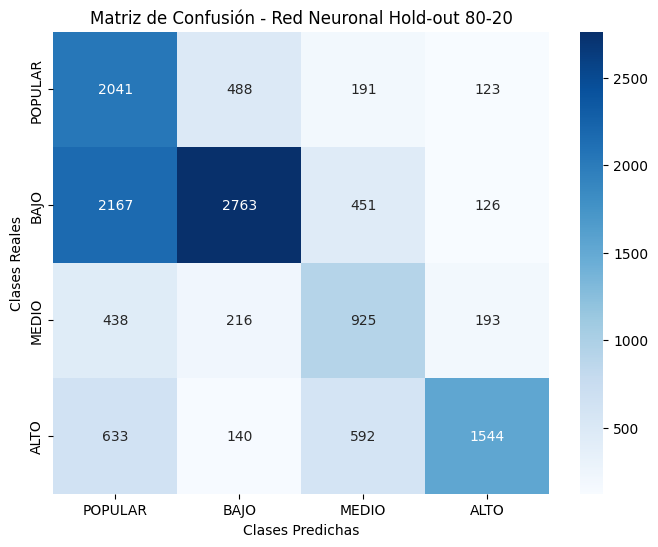

In [ ]:
from sklearn.neural_network import MLPClassifier

# 1. División Hold-out 80-20 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

#Inicialización del modelo con los parámetros por defecto de la librería
mlp = MLPClassifier(random_state=42)

#Entrenamiento del modelo
mlp.fit(X_train, y_train)

#Predicción sobre el conjunto de test
y_pred_rn = mlp.predict(X_test)

#Calcular la matriz
cm_rn = confusion_matrix(y_test, y_pred_rn)

#Configurar la visualización
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rn, annot=True, fmt='d', cmap='Blues',
            xticklabels=mapeo_clases.keys(),
            yticklabels=mapeo_clases.keys())

plt.title('Matriz de Confusión - Red Neuronal Hold-out 80-20')
plt.xlabel('Clases Predichas')
plt.ylabel('Clases Reales')
plt.show()

In [ ]:
me_dempeño(cm_rn)

Medidas de desempeño Clase 0
Recall : 0.7179
Precision : 0.3866
Specificity : 0.682175107970161
Balance Accuracy : 0.7
F1-Score : 0.5026
MCC : 0.3365856907382351
Medidas de desempeño Clase 1
Recall : 0.5017
Precision : 0.766
Specificity : 0.88782562466773
Balance Accuracy : 0.6948
F1-Score : 0.6063
MCC : 0.43008590804914865
Medidas de desempeño Clase 2
Recall : 0.522
Precision : 0.4284
Specificity : 0.8903987920774491
Balance Accuracy : 0.7062
F1-Score : 0.4706
MCC : 0.38021357484327867
Medidas de desempeño Clase 3
Recall : 0.5308
Precision : 0.7774
Specificity : 0.9563327405651058
Balance Accuracy : 0.7436
F1-Score : 0.6309
MCC : 0.5643520077979699
Medidas de desempeño Macro
Precision macro: 0.5896
Recall macro: 0.5681
Specificity macro: 0.8542
F1 macro: 0.5526
MCC macro: 0.4278
Balance Accuaracy macro: 0.7111
